In [46]:
#1 Import Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [59]:
#2 import data set from csv file
df = pd.read_csv("Data.csv")

print("\nClass Distribution:\n")
print(df["Decision"].value_counts())



Class Distribution:

Decision
Cinema      56
Stay-in     38
Shopping    34
Tennis      27
Name: count, dtype: int64


In [60]:
#3 Separate Features and Target
X = df.drop("Decision",axis=1)
y = df["Decision"]

In [61]:
#4 Define Preprocessing
categorical_features = ["Weather", "Parent", "Money"]
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [62]:
#5 Build Pipeline
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", DecisionTreeClassifier(
        criterion="entropy", #better for teaching
        max_depth=3,         #clean visualization
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=42
    ))
])


In [63]:
#6 Train on full Dataset
pipeline.fit(X,y)
print("\nTraining Accuracy:", pipeline.score(X,y))



Training Accuracy: 0.8838709677419355


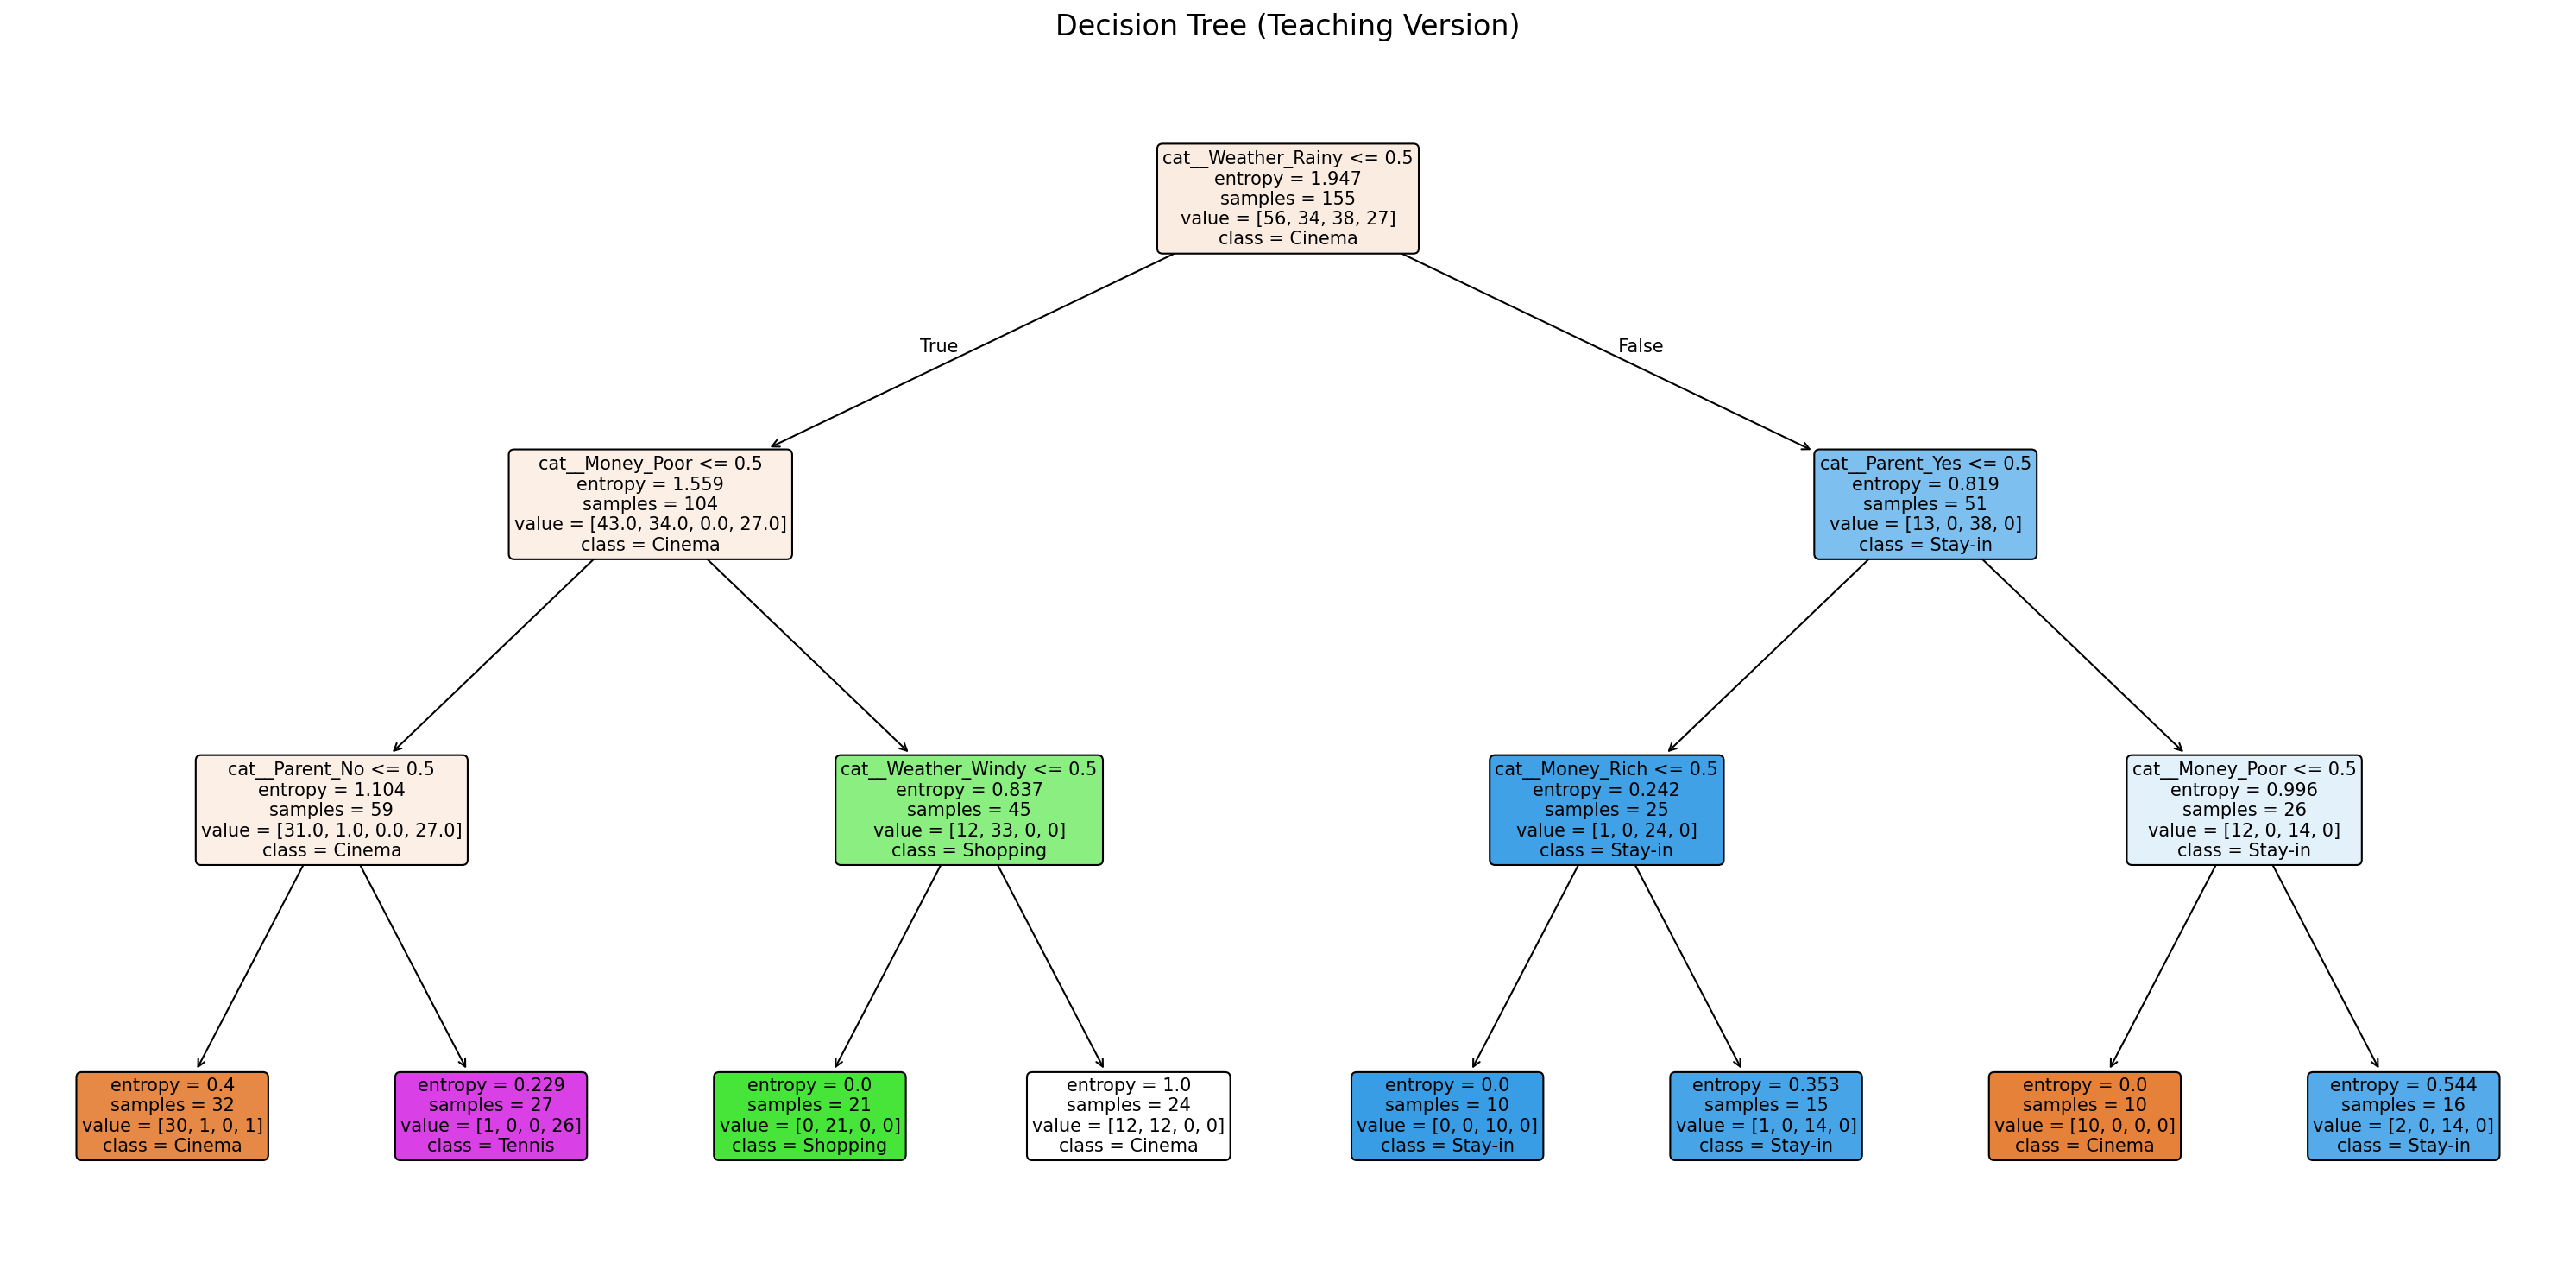

In [64]:
#7 Clean Decision Tree Visualization
feature_names = pipeline.named_steps["preprocessing"].get_feature_names_out()
plt.figure(figsize=(20,10), dpi=150)
plot_tree(
    pipeline.named_steps["model"],
    feature_names=feature_names,
    class_names=pipeline.named_steps["model"].classes_,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (Teaching Version)", fontsize=16)
plt.tight_layout()
plt.savefig("clean_decision_tree.png", dpi=300)
plt.show()

In [65]:
#8 User Input Prediction
def predict_user_input():
    print("\nEnter User Details:")
    weather = input("Weather (Sunny/Windy/Rainy): ")
    parent = input("Parent (Yes/No): ")
    money = input("Money (Rich/Poor): ")
    user_df = pd.DataFrame({
        "Weather": [weather],
        "Parent": [parent],
        "Money": [money]
    })

    prediction = pipeline.predict(user_df)[0]
    probability = pipeline.predict_proba(user_df)

    print("\nPredicted Decision:", prediction)
    print("Class Probabilities:")

    for cls, prob in zip(pipeline.named_steps["model"].classes_, probability[0]):
        print(f"{cls}: {round(prob*100,2)}%")
        
# Run Prediction
predict_user_input()



Enter User Details:


Weather (Sunny/Windy/Rainy):  sunny
Parent (Yes/No):  yes
Money (Rich/Poor):  rich



Predicted Decision: Cinema
Class Probabilities:
Cinema: 93.75%
Shopping: 3.12%
Stay-in: 0.0%
Tennis: 3.12%


In [68]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load CSV file
df = pd.read_csv("Data.csv")

# Features (X) and target (y)
X = df.drop("Decision", axis=1)
y = df["Decision"]


print(X)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

    Weather Parent Money
0     Sunny    Yes  Rich
1     Sunny     No  Rich
2     Windy    Yes  Rich
3     Rainy    Yes  Poor
4     Rainy     No  Rich
..      ...    ...   ...
150   Windy     No  Rich
151   Sunny    Yes  Rich
152   Rainy     No  Poor
153   Windy    Yes  Poor
154   Sunny     No  Rich

[155 rows x 3 columns]
X_train: (124, 3)
X_test: (31, 3)
y_train: (124,)
y_test: (31,)


In [69]:
X = df.drop("Decision",axis=1)
y = df["Decision"]
X_train


,Weather,Parent,Money
96,Windy,No,Poor
122,Rainy,No,Poor
82,Sunny,No,Rich
109,Sunny,Yes,Poor
65,Rainy,Yes,Rich
...,...,...,...
71,Rainy,Yes,Poor
106,Sunny,No,Poor
14,Rainy,Yes,Rich
92,Rainy,No,Poor


In [70]:
pipeline.fit(X_train, y_train)
print("\nTraining Accuracy: ",pipeline.score(X,y))


Training Accuracy:  0.8838709677419355


In [71]:
#prediction
pred=pipeline.predict(X_test)

In [72]:
acc=accuracy_score(y_test,pred)
acc

0.7741935483870968